# Generating synthetic data sets of a river bed column forced by monoperiodic river and aquifer temperature signals

2024 developped by Nicolas Flipo from demo_gen_test.ipynb created by Guillaume de Rochefort during MOLONARI 2022 

The object of this demo is to present a class responsible for generating a simulation of pressure and temperature sensor data in cases where data from the CAPTEUR project is not available. Based on the `synthetic_MOLONARI` class in `synthetic_MOLONARI.py`.

We will show the `synthetic_MOLONARI` object which allows generating purely periodic datasets with the possibility of Gaussian noise. We will illustrate the interaction of `synthetic_MOLONARI` with the `Column` class and the `layer` class.

The other demo file `demo_val_direct.ipynb` highlights a more global use of the classes from `synthetic_MOLONARI.py` and `val_analy.py`.


In [1]:
# démo time_series
from pyheatmy import *
import matplotlib.pyplot as plt
import numpy as np




## 1. Signal Parameterization
The signals are purely periodic, and it is necessary to choose the amplitude, period, and mean value of the river temperature, aquifer temperature, and pressure signals (boundary conditions). The T1, T2, T3 sensors in the shaft are only generated using the direct model.

A possible improvement for this class is to generate multi-periodic signals similar to the parameter lists of the layer, where a list of parameters for the different desired frequencies (diurnal, monthly, annual, etc.) would be provided.

In [2]:
# l'utilisateur saisit ses paramètres d'émulation de mesure
"""Fenêtre temporelle"""
# le format demandé est celui-ci : (y,m,d,h,mn,s) compatible avec la librairie datetime
t_debut = (2011, 8, 1)
t_fin = (2011, 8, 31, 23, 59, 59)
dt = 15*NSECINMIN # pas de temps en (s) # A AMELIORER AVEC UN CONVERTISSEUR AUTOMATIQUE D'UNITES

"""Conditions limites"""
# Température de la rivière
zeroT = 0
zeroT += ZERO_CELSIUS  #time_series works only with forcings in celsius. See if it is deeper in pyheatmy or not

T_riv_amp = 1
T_riv_offset = 12  + zeroT
nday = 30
P_T_riv = nday*NHOURINDAY*4*dt #monthly   period
# Température de l'aquifère
T_aq_amp = 0
T_aq_offset = 12 + zeroT
P_T_aq = -9999 # à mettre dans le init
# Pression différentielle
dH_amp = 0
dH_offset = 0.5 #1meter ?
P_dh = -9999 #14*24*4*dt


depth_sensors = [0.1, 0.2, 0.4, 0.6]
Zbottom = 8

"""Bruit de mesure"""
sigma_meas_P = 0.001
sigma_meas_T = 0.1

print("dt={0:.1f}s".format(dt))

dt=900.0s


## 2 Instantiating the objects `synthetic_MOLONARI` and `Column`
The generated object will have default values, and a series of methods must be used to update its essential parameters. In the initialisation of Time Series, the 3 intermediate temperature sensors T1, T2, T3, are initialized with a linear interpolation between Triv and Taq weighted by the distance from the sensor. Those values initialize the soil Column in a second step. For Time Series dH = Hriv-Haq

Initializing time series of synthetic_MOLONARI
param_time_dates: [(2011, 8, 1), (2011, 8, 31, 23, 59, 59), 900]
param_dH_signal: [0, -9999, 0.5]
param_T_riv_signal: [1, 2592000, 285.15]
param_T_aq_signal: [0, -9999, 285.15]
sigma_meas_P: 0.001
sigma_meas_T: 0.1
Entering Hydraulic head differential generation with amplitude 0, period of -9999, offset 0.5, dt 900.0 --> 
constant signal

Entering T_riv generation with amplitude 1, period of 2592000, offset 285.15, dt 900.0 --> 
periodic signal



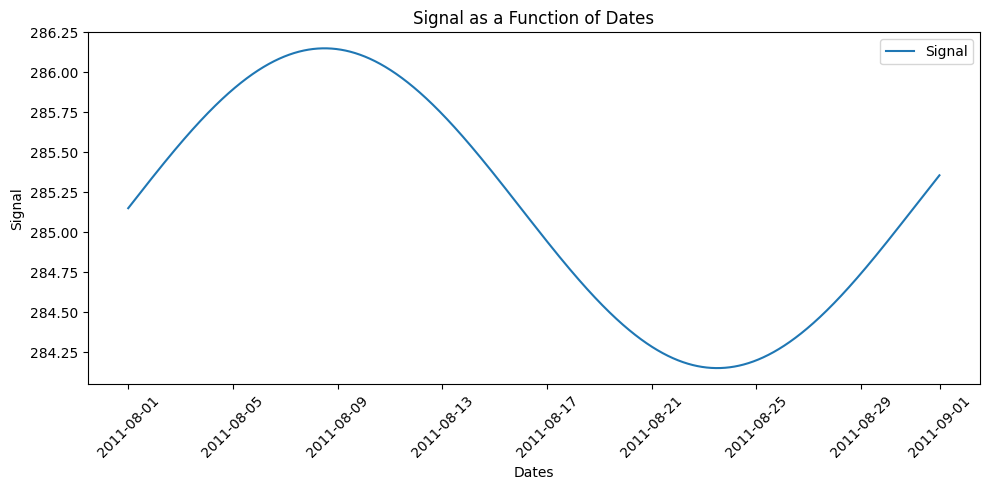

Entering T_aq generation with amplitude 0, period of -9999, offset 285.15, dt 900.0 --> 
constant signal

Generating Shaft with 4 sensors
4 sensors in the shaft
Temperature of Sensor 0 : [285.15       285.15181805 285.15363609 ... 285.3179211  285.31970146
 285.32148101]
Temperature of Sensor 1 : [285.15       285.15145444 285.15290887 ... 285.28433688 285.28576117
 285.28718481]
Temperature of Sensor 2 : [285.15       285.15072722 285.15145444 ... 285.21716844 285.21788058
 285.2185924 ]
Temperature of Sensor 3 : [285.15 285.15 285.15 ... 285.15 285.15 285.15]
dH : [(datetime.datetime(2011, 8, 1, 0, 0), (np.float64(0.4993217546255978), np.float64(285.1027321703254))), (datetime.datetime(2011, 8, 1, 0, 15), (np.float64(0.5009904875491139), np.float64(285.004408176612))), (datetime.datetime(2011, 8, 1, 0, 30), (np.float64(0.4991160533040402), np.float64(285.0428838403046))), (datetime.datetime(2011, 8, 1, 0, 45), (np.float64(0.49911850123804724), np.float64(285.3000455895851))), (dateti

In [3]:
"""Instanciation de l'objet Time_series"""
# un dictionnaire qui facilite le paramétrage avec des variables globales définies plus haut
time_series_dict_user1 = {
    "offset":.0,
    "depth_sensors":depth_sensors,
	"param_time_dates": [t_debut, t_fin, dt], 
    "param_dH_signal": [dH_amp, P_dh, dH_offset], #En vrai y aura une 4e valeur ici mais ca prendra en charge pareil
	"param_T_riv_signal": [T_riv_amp, P_T_riv, T_riv_offset],
    "param_T_aq_signal": [T_aq_amp, P_T_aq, T_aq_offset],
    "sigma_meas_P": sigma_meas_P,
    "sigma_meas_T": sigma_meas_T, #float
}
# instanciation du simulateur de données
emu_observ_test_user1 = synthetic_MOLONARI.from_dict(time_series_dict_user1)

# print("Checking params synthetic_MOLONARI")
# print("param_time_dates:", emu_observ_test_user1._param_dates)
# print("param_dH_signal:", emu_observ_test_user1._param_dH)
# print("param_T_riv_signal:", emu_observ_test_user1._param_T_riv)
# print("param_T_aq_signal:", emu_observ_test_user1._param_T_aq)
# print("sigma_meas_P:", emu_observ_test_user1._sigma_P)
# print("sigma_meas_T:", emu_observ_test_user1._sigma_T)


print(f"dH : {emu_observ_test_user1._molonariP_data}")
print(f"Tshaft : {emu_observ_test_user1._T_Shaft_measures}")


In [4]:
# l'utilisateur génère un dictionnaire avec les données importantes de la colonne
Couche = {
    "name": "Couche en sable",
    "zLow": Zbottom,
    "moinslog10IntrinK":-np.log10(8e-11),
    "n": 0.15,
    "lambda_s": 1,
    "rhos_cs": 4e6,
    "q": 0,
}

# modèle une couche
Layer1 = Layer.from_dict(Couche)

print(f"Layer: {Layer1}")

nbcells = 100
# on utilise les mesures générées précédemment dans les init "dH_measures" et "T_measures"
col_dict = {
	"river_bed": 1., 
    "depth_sensors": depth_sensors, #En vrai y aura une 4e valeur ici mais ca prendra en charge pareil
	"offset": .0,
    "dH_measures": emu_observ_test_user1._molonariP_data,
    "T_measures": emu_observ_test_user1._T_Shaft_measures,
    "nb_cells" : nbcells,
    "sigma_meas_P": 0.01, #float
    "sigma_meas_T": 0.1, #float
}
col = Column.from_dict(col_dict,verbose=True)
col.set_layers(Layer1)

Layer: Couche en sable : ends at 8 m. Param(moinslog10IntrinK=np.float64(10.096910013008056), n=0.15, lambda_s=1, rhos_cs=4000000.0, q=0)
Column created with success
Number of time steps: 2976
Time step in days: 0.01041316644265233
T_riv: [285.10273217 285.00440818 285.04288384 ... 285.36262927 285.38421247
 285.43765317]
T_aq: [285.16966124 285.15112602 285.15526679 ... 285.27546775 285.11612753
 285.04485057]
dH : [0.49932175 0.50099049 0.49911605 ... 0.49829772 0.50116664 0.49967829]
list of dates   : [datetime.datetime(2011, 8, 1, 0, 0), datetime.datetime(2011, 8, 1, 0, 15), datetime.datetime(2011, 8, 1, 0, 30), datetime.datetime(2011, 8, 1, 0, 45), datetime.datetime(2011, 8, 1, 1, 0), datetime.datetime(2011, 8, 1, 1, 15), datetime.datetime(2011, 8, 1, 1, 30), datetime.datetime(2011, 8, 1, 1, 45), datetime.datetime(2011, 8, 1, 2, 0), datetime.datetime(2011, 8, 1, 2, 15), datetime.datetime(2011, 8, 1, 2, 30), datetime.datetime(2011, 8, 1, 2, 45), datetime.datetime(2011, 8, 1, 3, 0),

## 3 Generating temperature in the river bed

We use the [_measures_column_one_layer(col, layers_list)] method, which updates the measurements for T1, T2 and T3 at each point in time with the direct model pyheatmy. The sensor time series are then perturbated with a gaussian noise in the Time series object. We display the temperature simulated at sensors.

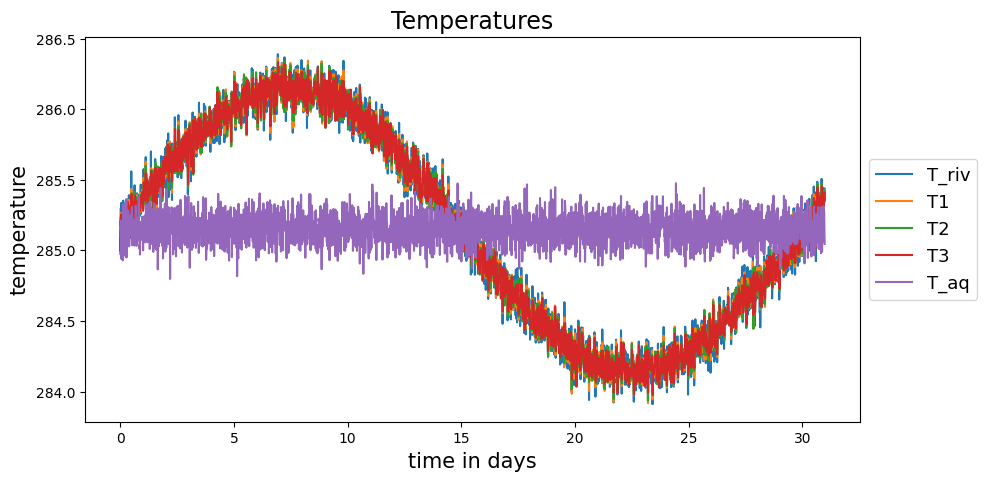

In [5]:

# print(emu_observ_test_user1._T_Shaft)
emu_observ_test_user1._measures_column_one_layer(col)
#emu_observ_test_user1._plot_molonariT_data()
col.plot_temperature_at_sensors(verbose=False)



The simulated temperatures with pyheatmy are compared to the initial values of the Shaft which were interpolated. Without surprise, they are very different for an advective configuration (high k value)

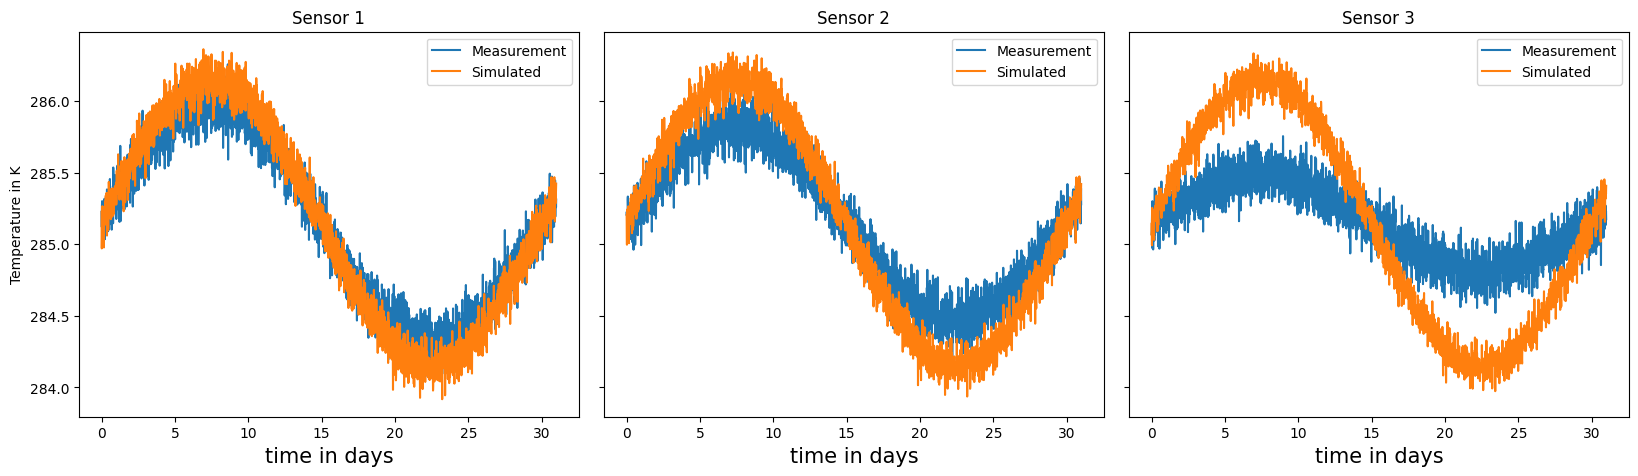

In [6]:

col.plot_compare_temperatures_sensors()

Here are temperature profiles simulated by pyheatmy

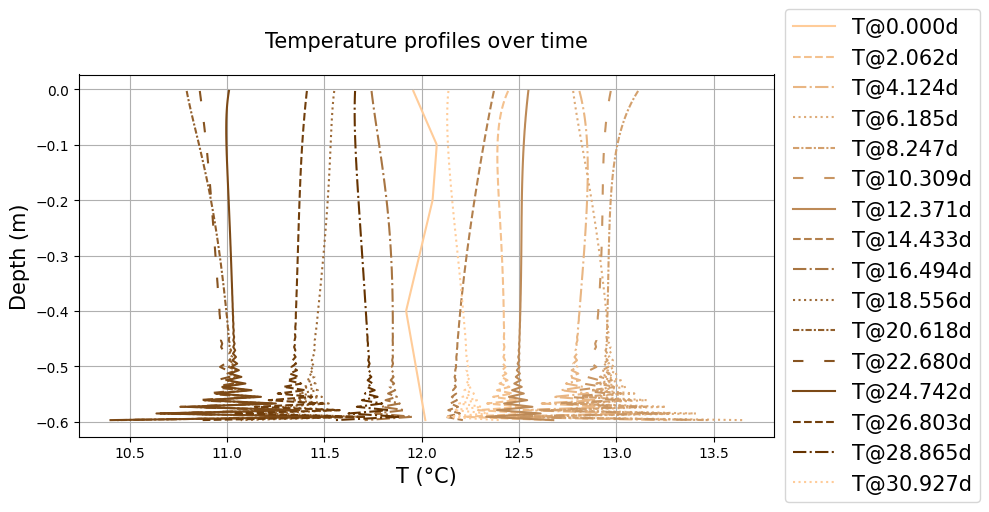

In [7]:
nt = len(col._temperatures[0,:])
dplot=15
col.plot_temperatures_umbrella(round(nt/dplot))



Now creating a new column created with the generated case study

[(datetime.datetime(2011, 8, 1, 0, 0), array([285.19057297, 285.11567183, 285.00179718, 285.209224  ])), (datetime.datetime(2011, 8, 1, 0, 15), array([284.76747447, 285.12811664, 285.0363647 , 285.05717336])), (datetime.datetime(2011, 8, 1, 0, 30), array([285.11075899, 284.90508592, 285.14760804, 285.42857468])), (datetime.datetime(2011, 8, 1, 0, 45), array([285.27872284, 285.23936761, 285.17363513, 285.21247007])), (datetime.datetime(2011, 8, 1, 1, 0), array([285.27503501, 285.28118866, 285.27902639, 284.93903082])), (datetime.datetime(2011, 8, 1, 1, 15), array([285.38765709, 285.21756378, 285.18715841, 284.91925474])), (datetime.datetime(2011, 8, 1, 1, 30), array([284.90689311, 285.2715846 , 285.30280803, 285.04575705])), (datetime.datetime(2011, 8, 1, 1, 45), array([285.23339193, 285.26321273, 285.12500025, 285.03112494])), (datetime.datetime(2011, 8, 1, 2, 0), array([285.33740907, 285.21161862, 285.11024539, 285.21173312])), (datetime.datetime(2011, 8, 1, 2, 15), array([285.1217033

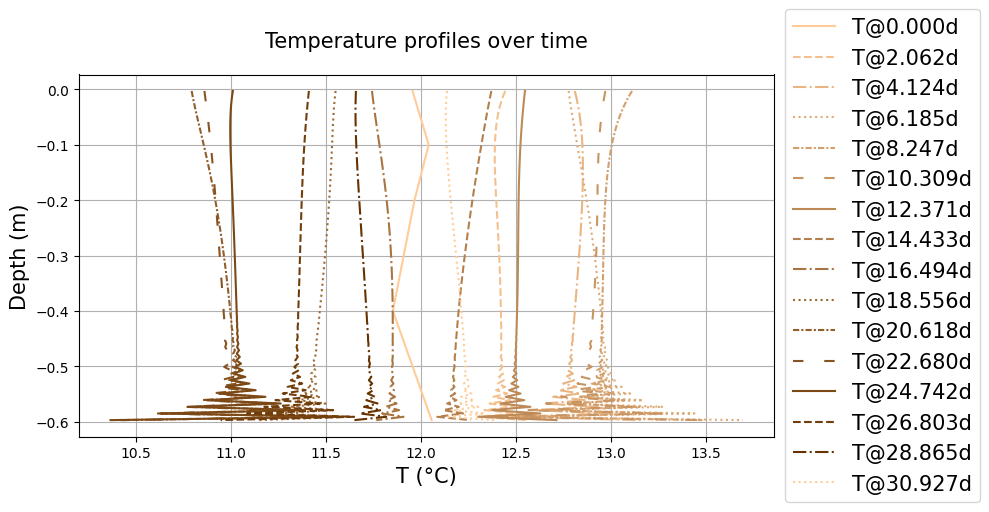

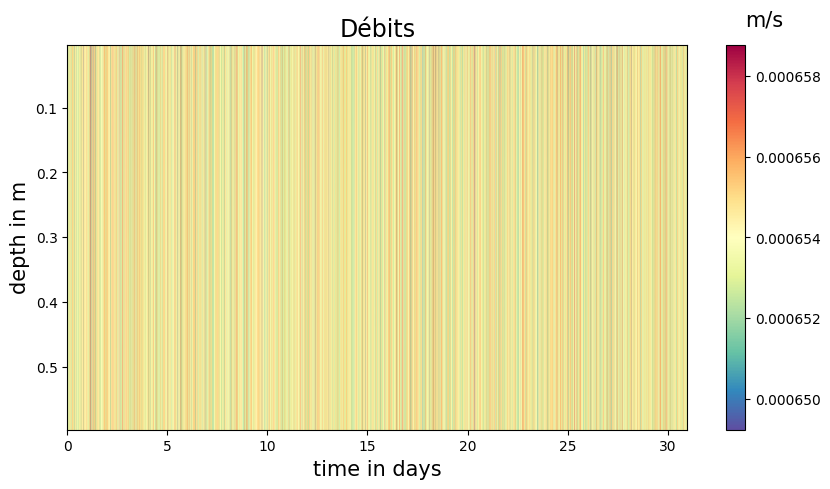

RMSE at sensor 0 : 0.10254971572801452
RMSE at sensor 1 : 0.09824548763212863
RMSE at sensor 2 : 0.09887983694234917
Total RMSE : 0.09990969620898812
Plotting Température in column. time series have nrecords =  2976
Creating C:\Users\rbarr/OUTPUT_MOLONARI1D/generated_data/VirtualPoint/VirtualPoint_P_measures.csv
Creating C:\Users\rbarr/OUTPUT_MOLONARI1D/generated_data/VirtualPoint/VirtualPoint_T_measures.csv
Creating C:\Users\rbarr/OUTPUT_MOLONARI1D/generated_data/VirtualPoint/VirtualPoint_info.csv
File C:\Users\rbarr/OUTPUT_MOLONARI1D/generated_data/VirtualPoint/VirtualPoint_P_measures.csv closed successfully.
File C:\Users\rbarr/OUTPUT_MOLONARI1D/generated_data/VirtualPoint/VirtualPoint_T_measures.csv closed successfully.
File C:\Users\rbarr/OUTPUT_MOLONARI1D/generated_data/VirtualPoint/VirtualPoint_info.csv closed successfully.
Creating C:\Users\rbarr/OUTPUT_MOLONARI1D/generated_data/VirtualLabo/pressure_sensors/Pvirtual.csv
Printing Sensor file 1
File C:\Users\rbarr/OUTPUT_MOLONARI

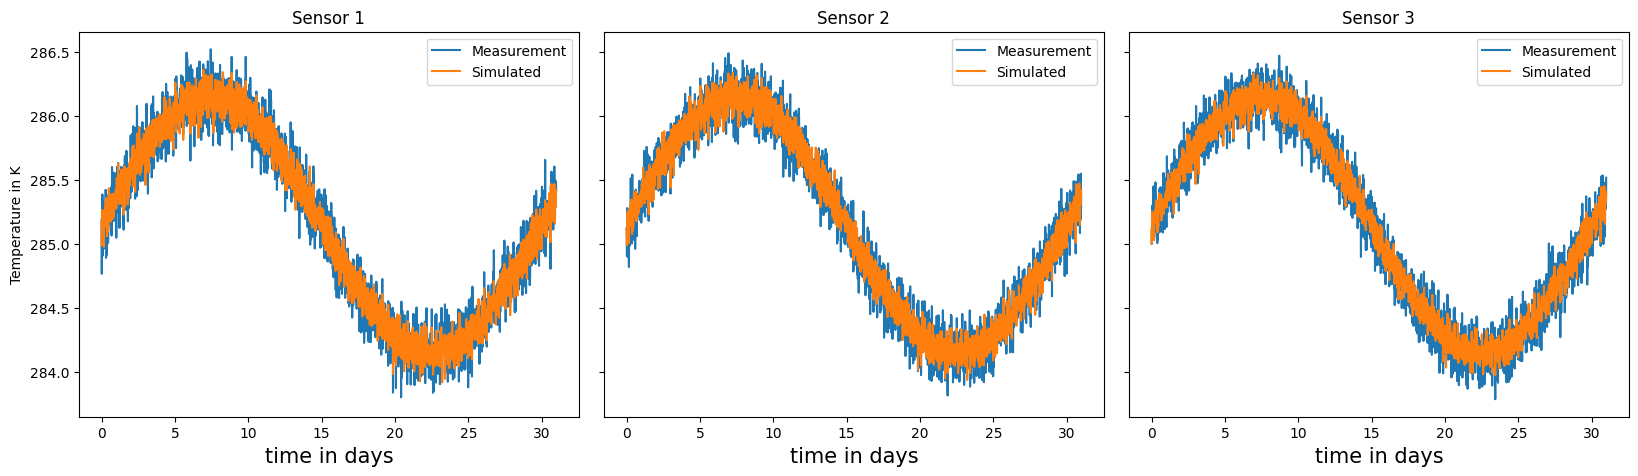

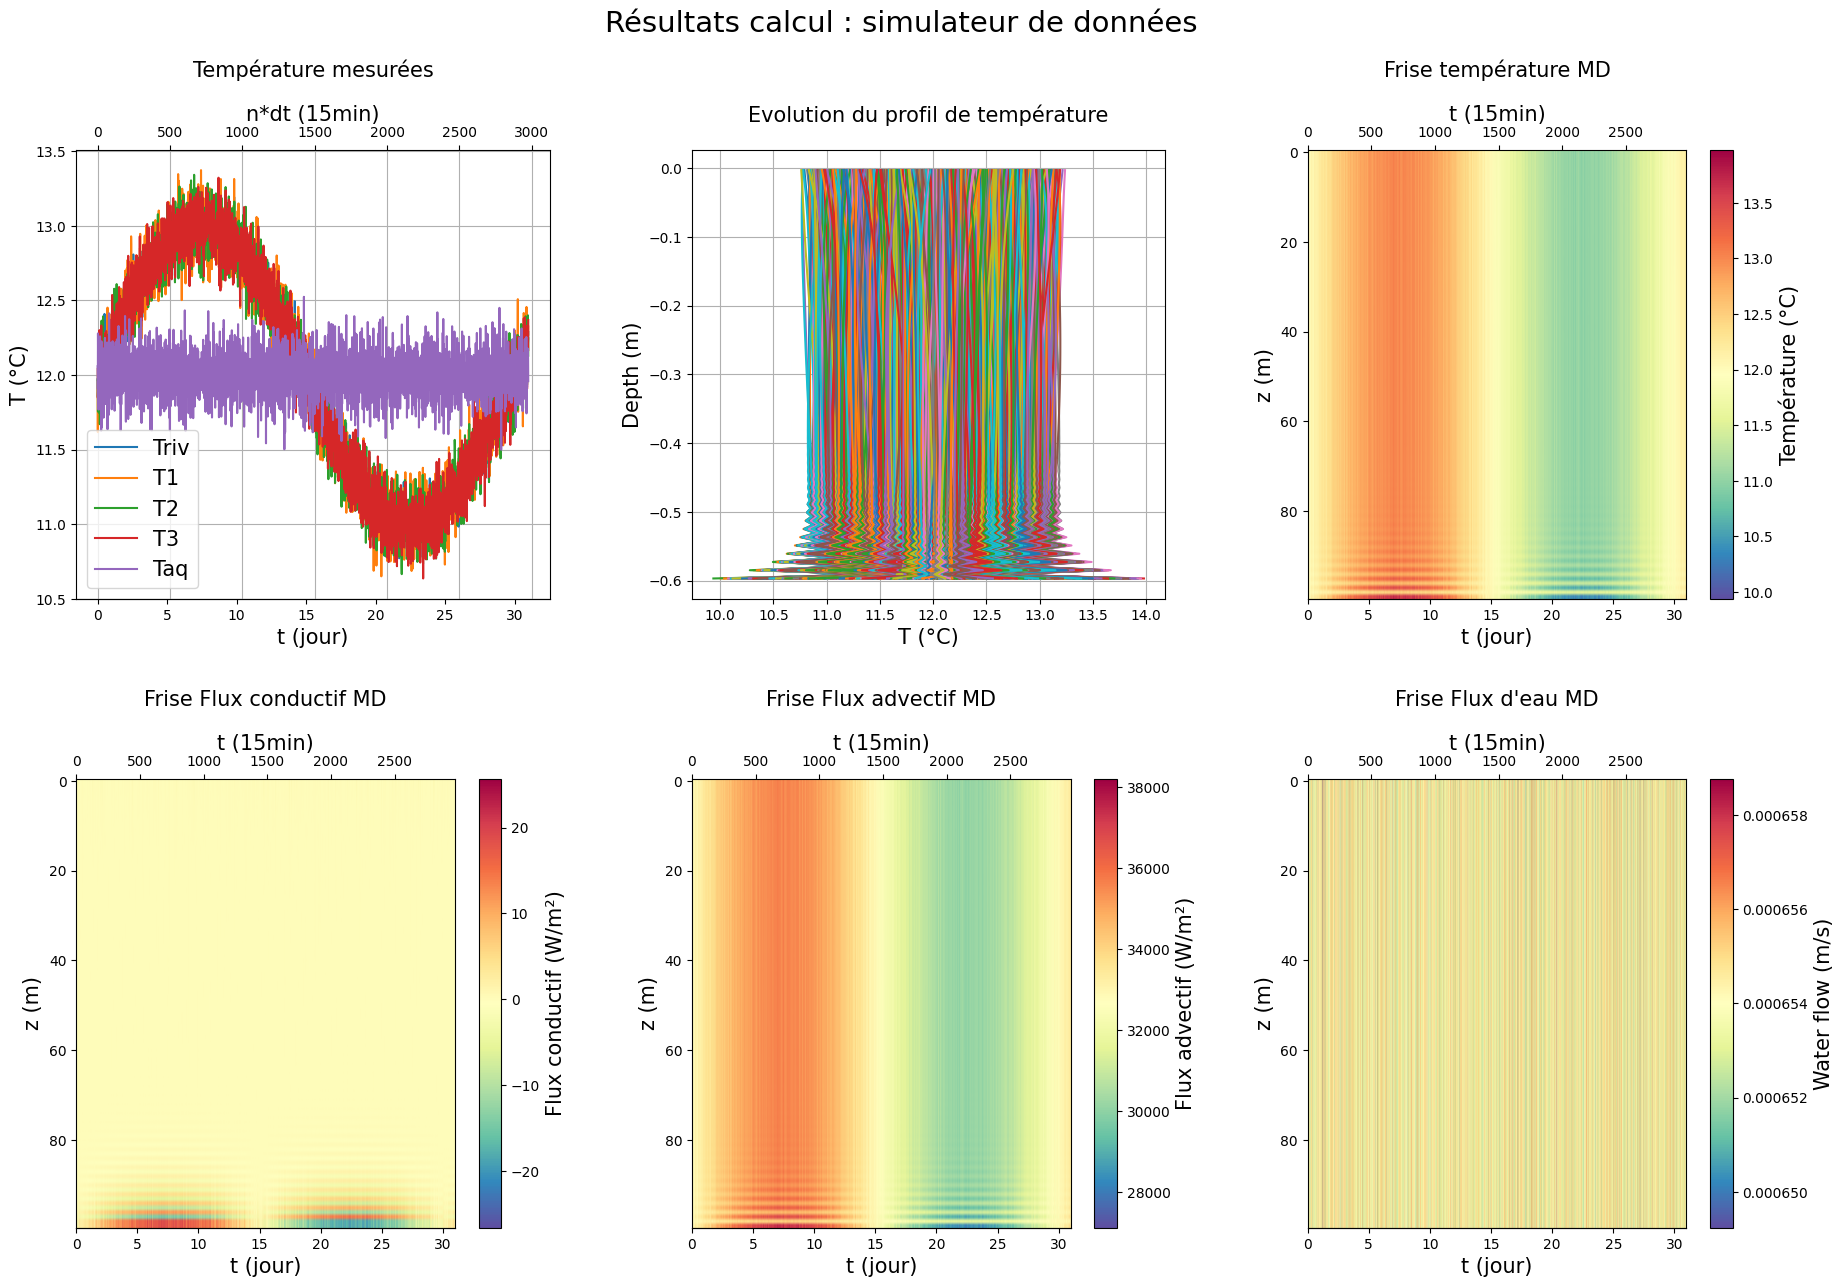

In [8]:
print(emu_observ_test_user1._molonariT_data)

# on utilise les mesures générées précédemment dans les init "dH_measures" et "T_measures"
newCol_dict = {
	"river_bed": 1., 
    "depth_sensors": depth_sensors, #En vrai y aura une 4e valeur ici mais ca prendra en charge pareil
	"offset": .0,
    "dH_measures": emu_observ_test_user1._molonariP_data,
    "T_measures": emu_observ_test_user1._molonariT_data,
    "nb_cells" : nbcells,
    "sigma_meas_P": None, #float
    "sigma_meas_T": None, #float
}
newCol = Column.from_dict(newCol_dict)
newCol.set_layers(Layer1)
newCol.compute_solve_transi(verbose=True)

nt = len(newCol._temperatures[0,:])
dplot=15
newCol.plot_temperatures_umbrella(round(nt/dplot))

flows = newCol.get_flows_solve()
unitLeg="m/s"
title="Débits"
newCol.plot_it_Zt(flows,title,unitLeg,1.04,2)

newCol.print_RMSE_at_sensor()
newCol.plot_compare_temperatures_sensors()
newCol.plot_CALC_results()
newCol.print_in_file_processed_MOLONARI_dataset(zeroT=0)

# Multilayered riverbed -- No printing option activated

## Warning
It seems that there is a bug at the interface between layers and also if a sensor is located at the interface

In [9]:
t_debut = (2011, 8, 1)
t_fin = (2011, 8, 31, 23, 59, 59)
dt = 15*60 # pas de temps en (s)

T_riv_amp = 2
T_riv_offset = 20 + ZERO_CELSIUS
P_T_riv = 72*4*dt

T_aq_amp = 0
T_aq_offset = 12 + ZERO_CELSIUS
P_T_aq = 9999 # à mettre dans le init

dH_amp = 0
dH_offset = 0.1
P_dh = -9999 #14*24*4*dt

Zbottom = 0.6
depth_sensors = [.1, .25, .3, .4, Zbottom] # le code fonctionne avec n capteurs, watch the compatibility with Zbottom

In [10]:
time_series_dict_user4 = {
    "offset" : 0,
    "depth_sensors":depth_sensors,
	"param_time_dates": [t_debut, t_fin, dt], 
    "param_dH_signal": [dH_amp, P_dh, dH_offset], #En vrai y aura une 4e valeur ici mais ca prendra en charge pareil
	"param_T_riv_signal": [T_riv_amp, P_T_riv, T_riv_offset],
    "param_T_aq_signal": [T_aq_amp, P_T_aq, T_aq_offset],
    "sigma_meas_P": 0.05,
    "sigma_meas_T": 0.1, #float
}

Initializing time series of synthetic_MOLONARI
param_time_dates: [(2011, 8, 1), (2011, 8, 31, 23, 59, 59), 900]
param_dH_signal: [0, -9999, 0.1]
param_T_riv_signal: [2, 259200, 293.15]
param_T_aq_signal: [0, 9999, 285.15]
sigma_meas_P: 0.05
sigma_meas_T: 0.1
Entering Hydraulic head differential generation with amplitude 0, period of -9999, offset 0.1, dt 900.0 --> 
constant signal

Entering T_riv generation with amplitude 2, period of 259200, offset 293.15, dt 900.0 --> 
periodic signal



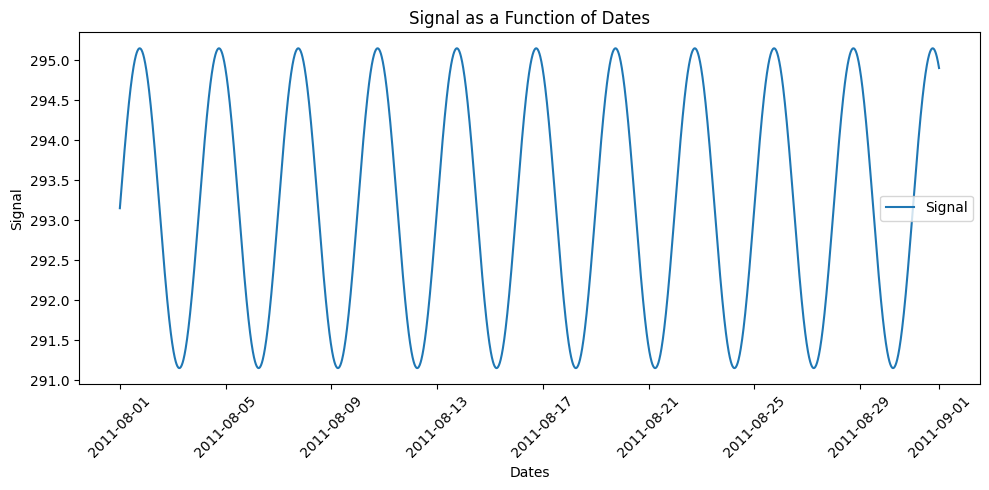

Entering T_aq generation with amplitude 0, period of 9999, offset 285.15, dt 900.0 --> 
periodic signal



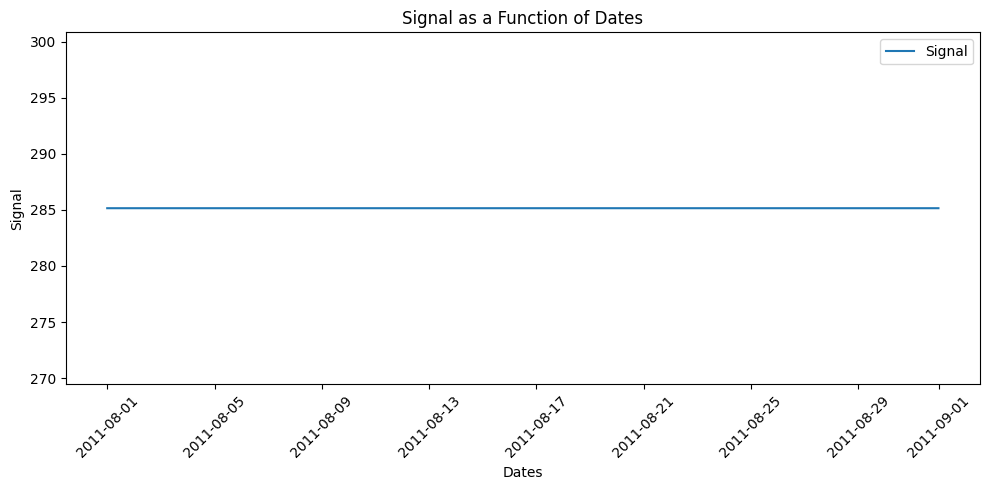

Generating Shaft with 5 sensors
5 sensors in the shaft
Temperature of Sensor 0 : [291.81666667 291.85302481 291.88936565 ... 293.31145457 293.29501806
 293.27787793]
Temperature of Sensor 1 : [289.81666667 289.84211737 289.86755595 ... 290.8630182  290.85151264
 290.83951455]
Temperature of Sensor 2 : [289.15       289.17181489 289.19361939 ... 290.04687274 290.03701083
 290.02672676]
Temperature of Sensor 3 : [287.81666667 287.83120992 287.84574626 ... 288.41458183 288.40800722
 288.40115117]
Temperature of Sensor 4 : [285.15 285.15 285.15 ... 285.15 285.15 285.15]


In [11]:
emu_observ_test_user4 = synthetic_MOLONARI.from_dict(time_series_dict_user4)
# emu_observ_test_user4._generate_all_series()



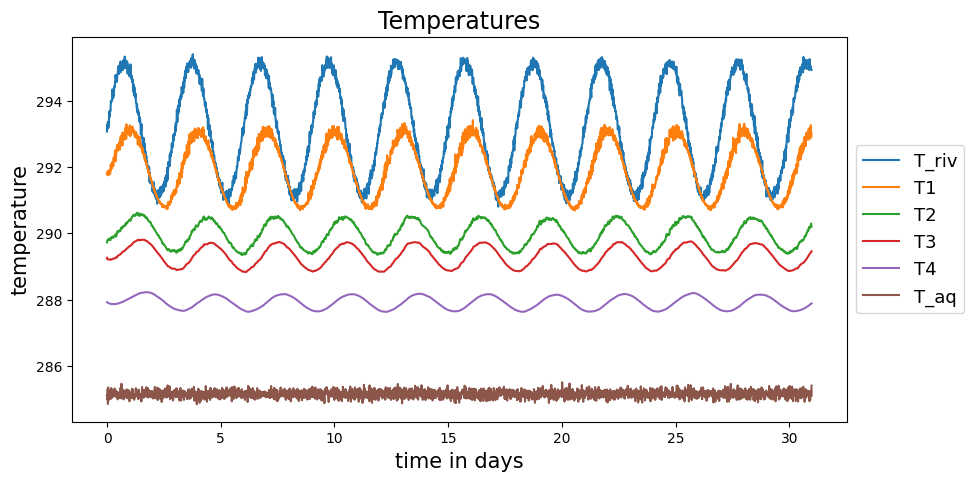

--- Compute Solve Transi ---
gravier : ends at 0.2 m. Param(moinslog10IntrinK=11, n=0.4, lambda_s=2, rhos_cs=4000000.0, q=0)
Couche en sable : ends at 0.6 m. Param(moinslog10IntrinK=14, n=0.1, lambda_s=2, rhos_cs=4000000.0, q=0)
Hinter [0.08806273 0.08801872 0.        ]
conditions aux limites
H_riv [0.08806273 0.06651892 0.14643056 ... 0.00263729 0.04366101 0.07333497]
H_aq [0. 0. 0. ... 0. 0. 0.]
échantillons du profondeur: ...  0.195 0.201  ...
le profondeur d'interface:  0.2
type cara asymetric
Done.


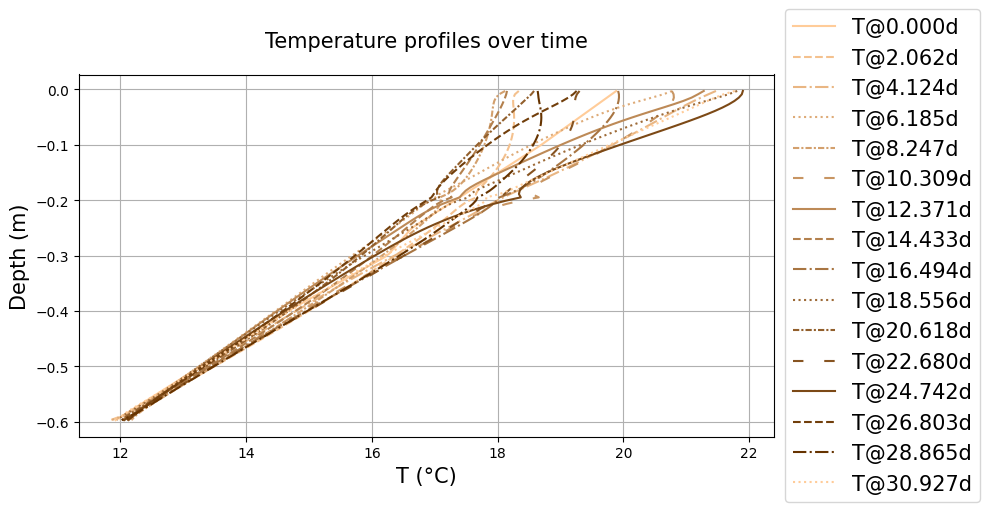

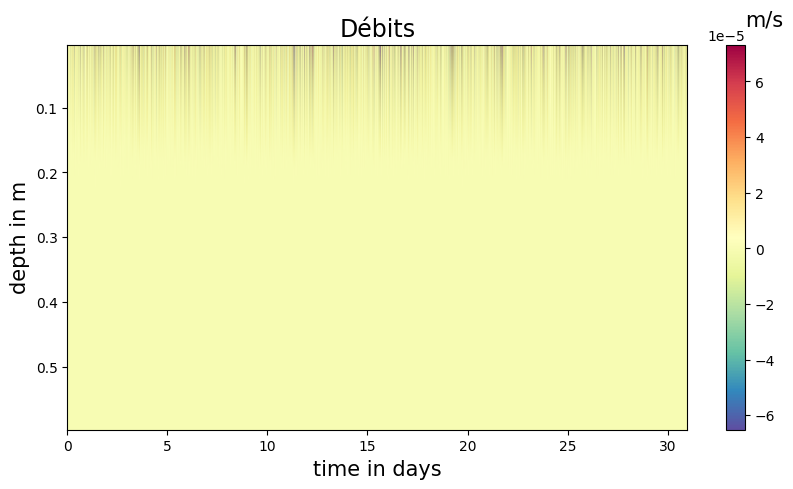

RMSE at sensor 0 : 0.0997830244412012
RMSE at sensor 1 : 0.10233046879302098
RMSE at sensor 2 : 0.09780689111276196
RMSE at sensor 3 : 0.10016950836369067
Total RMSE : 0.10003536270364591
Plotting Température in column. time series have nrecords =  2976


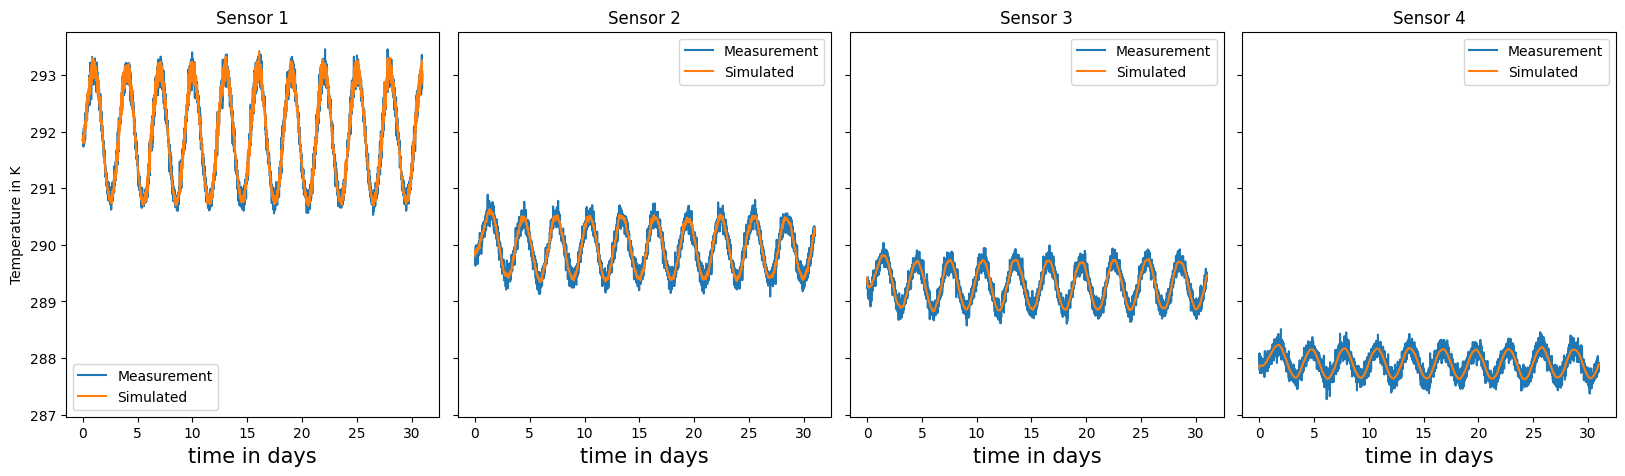

In [ ]:
# l'utilisateur génère un dictionnaire avec les données importantes de la colonne
Layer1 = {
    "name": "gravier",
    "zLow": .2,
    "moinslog10IntrinK":11,
    "n": .4,
    "lambda_s": 2,
    "rhos_cs": 4e6,
    "q": 0,
}

Layer2 = {
    "name": "Couche en sable",
    "zLow": Zbottom,
    "moinslog10IntrinK":14,
    "n": .1,
    "lambda_s": 2,
    "rhos_cs": 4e6,
    "q": 0,
}

# on utilise les mesures générées précédemment
col_dict4 = {
	"river_bed": 1., 
    "depth_sensors": depth_sensors, #En vrai y aura une 4e valeur ici mais ca prendra en charge pareil
	"offset": .0,
    "dH_measures": emu_observ_test_user4._molonariP_data,
    "T_measures": emu_observ_test_user4._molonariT_data,
    "nb_cells" : nbcells,
    "sigma_meas_P": emu_observ_test_user4._sigma_P, #float
    "sigma_meas_T": emu_observ_test_user4._sigma_T, #float
}

col4 = Column.from_dict(col_dict4)

# modèle une couche
col4.set_layers([Layer.from_dict(Layer1),Layer.from_dict(Layer2)])

# print(emu_observ_test_user1._T_Shaft)
emu_observ_test_user4._measures_column_one_layer(col4)
#emu_observ_test_user1._plot_molonariT_data()
col4.plot_temperature_at_sensors(verbose=False)


# on utilise les mesures générées précédemment dans les init "dH_measures" et "T_measures"
newCol4_dict = {
	"river_bed": 8., 
    "depth_sensors": depth_sensors, #En vrai y aura une 4e valeur ici mais ca prendra en charge pareil
	"offset": .0,
    "dH_measures": emu_observ_test_user4._molonariP_data,
    "T_measures": emu_observ_test_user4._molonariT_data,
    "nb_cells" : nbcells,
    "sigma_meas_P": None, #float
    "sigma_meas_T": None, #float
}
ncol4 = Column.from_dict(newCol4_dict)
ncol4.set_layers([Layer.from_dict(Layer1),Layer.from_dict(Layer2)])
ncol4.compute_solve_transi(verbose=True)

nt = len(ncol4._temperatures[0,:])
dplot=15
ncol4.plot_temperatures_umbrella(round(nt/dplot))

flows = ncol4.get_flows_solve()
unitLeg="m/s"
title="Débits"
ncol4.plot_it_Zt(flows,title,unitLeg,1.04,2)

ncol4.print_RMSE_at_sensor()
ncol4.plot_compare_temperatures_sensors()
ncol4.plot_CALC_results()
#ncol4.print_in_file_processed_MOLONARI_dataset(zeroT=0) #No printing of the multilayer case study for the usage of demoInversion.ipynb


